In [1]:
%load_ext autoreload
%autoreload 2

In [5]:
import numpy as np

from mad.objs.constants import EARTH_SETTINGS, G
from mad.objs.projectiles import Projectile, ProjectileConfig
from mad.objs.planets import Planet, PlanetConfig
from mad.logger import SourceLogger
import matplotlib.pyplot as plt

logger = SourceLogger()

In [6]:
EARTH_SETTINGS["position"] = [0.0, 0.0]
earth = Planet(PlanetConfig(**EARTH_SETTINGS))

earth.escape_velocity, earth.gravity_at_surface

(np.float64(11185.79353278485), np.float64(-9.819649737724955))

In [10]:
projectile_cfg = ProjectileConfig(
    **{
        "position": [earth.radius + 1000, 0.0],
        "mass": 50,
        "velocity": [100, np.sqrt(G * earth.mass / earth.radius) * 1.2],
    }
)

proj = Projectile(projectile_cfg)
proj.area = 0.0 # no drag
dt = 1
t = 0.0
time_scale = [t]
while t < 20000:
    proj.step(dt, planet=earth)

    time_scale.append(t)
    t += dt
    if not proj.active:
        break

logger["Simulation"].info(f" Simulation ended at {t:.2f}")

21:18:12 | INFO     | Projectile   | Projectile landed on the ground!
21:18:12 | INFO     | Simulation   |  Simulation ended at 12061.00


In [11]:
pos = np.asarray(proj.history.position)
vel = np.asarray(proj.history.velocity)

posx, posz = pos[:, 0], pos[:, 1]
velx, velz = vel[:, 0], vel[:, 1]

altitude = np.sqrt(posx**2 + posz**2) - earth.radius
velout = np.sqrt(velx**2 + velz**2)

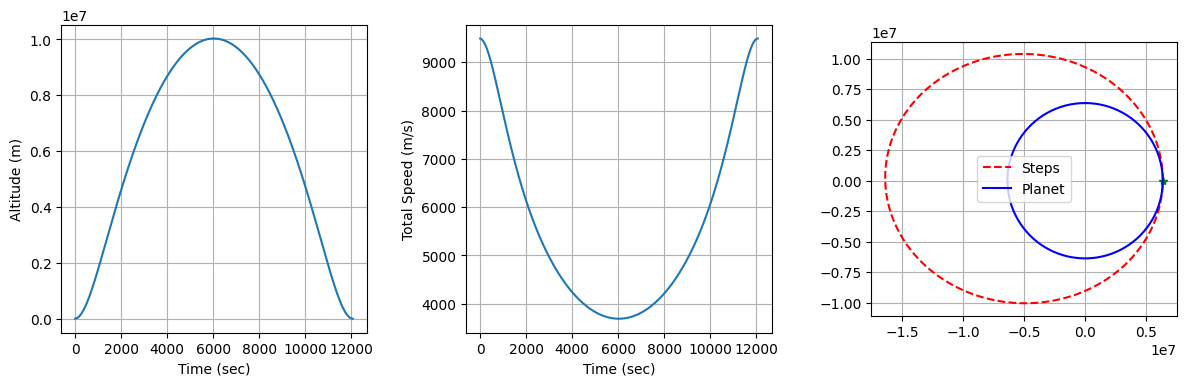

In [12]:
fig, ax = plt.subplots(ncols=3, nrows=1, figsize=(12, 4))
ax.flatten()

ax[0].plot(time_scale, altitude)
ax[0].set_xlabel("Time (sec)")
ax[0].set_ylabel("Altitude (m)")
ax[0].grid()

ax[1].plot(time_scale, velout)
ax[1].set_xlabel("Time (sec)")
ax[1].set_ylabel("Total Speed (m/s)")
ax[1].grid()

ax[2].plot(posx, posz, "r--", label="Steps")
ax[2].plot(posx[0], posz[0], "g*")
theta = np.linspace(0, 2 * np.pi, 100)
xplanet = earth.radius * np.sin(theta)
yplanet = earth.radius * np.cos(theta)
ax[2].plot(xplanet, yplanet, "b-", label="Planet")
ax[2].set_aspect("equal")
ax[2].grid()
ax[2].legend()

fig.tight_layout(pad=1.2)